## **Critère de détection de l'algorithme 1 et 2 SD**

Dans ce markdown nous allons appliquer la méthode la plus 'fiable' d'après l'article d'Hanspacha et al pour détecter si un vendeur utilise un outil de tarification algorithmique pour ses produits.

Cette méthode consiste à compter le nombre de fois que que le produit a changé de prix rammené au nombre d'observations de ce produit. 
Puis nous normalisons la distribution des changements de prix par paire vendeur-produit et considérons qu'il s'agit d'une tarification algorithmique si elle dépasse la moyenne de 2 (1) écarts-types (SD) dans la distribution normalisée globale du produit en question.

Soit $N_{ij}$ le taux de changement de prix pour la paire vendeur-produit $(i,j)$, défini par :

$$
N_{ij} = \frac{\text{Nombre de changements de prix pour la paire } (i,j)}{\text{Nombre d'observations pour la paire } (i,j)}
$$

On normalise ensuite la distribution des $N_{ij}$ pour chaque produit $j$ en calculant le score-z :

$$
z_{ij} = \frac{N_{ij} - \mu_j}{\sigma_j}
$$

où :
- $\mu_j$ est la moyenne des $N_{ij}$ pour le produit $j$,
- $\sigma_j$ est l'écart-type des $N_{ij}$ pour le produit $j$.

On considère qu'il s'agit d'une tarification algorithmique si :

$$
z_{ij} > k,
$$

avec $k = 2$ (ou $k = 1$ selon la méthode choisie).



In [329]:
import pandas as pd
df = pd.read_csv('../Formatage/LECLERC_ordered.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)


Nous calculons la variation du prix d'un produit à un moment 
𝑡
 comme étant la différence entre le prix au temps 
𝑡
 (prix_t) et le prix au temps 
𝑡
−
1
 (prix_(t-1)).

Nous partons de l'hypothèse qu'une absence du produit de plus de 24 heures est due à une rupture de stock, pour deux raisons principales :

1. Tous les produits observés sur le site étaient indiqués comme 'en stock'.
2. Leclerc n'indique pas supprimer des vendeurs dans ses critères de classement. 

Nous supposons donc que si un vendeur n'apparaît plus, cela résulte soit d'un choix du vendeur, soit d'une rupture de stock.
En conséquence, nous considérons que tout produit qui disparaît de nos données pour une période supérieure à 24 heures a une variation de prix en 
𝑡 considérée comme nulle par rapport à son dernier prix recensé.


In [330]:
# 1. Trier le DataFrame par 'ID' et 'Timestamp'
df = df.sort_values(by=['ID', 'Timestamp'])
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# 2. Pour chaque id, récupérer le prix de la période précédente avec shift(1)
df['price_previous'] = df.groupby('ID')['Price'].shift(1)
df['time_diff'] = df.groupby('ID')['Timestamp'].diff()

#On rajoute une condition de temps, cad si le produit est présent dans les 24h avant
#on considère qu'il a un prix précédent sinon -> Nan
mask = df['time_diff'] < pd.Timedelta(hours=24)
df['price_previous'] = df['price_previous'].where(mask)

# # 4.. Calculer la variation : prix_t - prix_t-1, mais seulement si la condition de temps est remplie
df['variation'] = df['Price'] - df['price_previous']

df['variation'].fillna(0,inplace=True)
df['variation_bool'] = (df['variation'] != 0).astype(int)

C:\Users\zoero\AppData\Local\Temp\ipykernel_6672\1864550767.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['variation'].fillna(0,inplace=True)


Nous calculons la moyenne et l'écart-type des variations par type de téléphone, puis nous normalisons les données des paires vendeurs-produits.

In [331]:
stats =  df.groupby('Product Name')['variation_bool'].agg(['mean','std'])
stats_ID = df.groupby(['Product Name','ID'])['variation_bool'].agg(['mean', 'sum']).reset_index()
stats_ID.rename(columns={'mean':'mean_ID'}, inplace=True )

stats_ID = stats_ID.merge(stats, on='Product Name', how='left')
stats_ID.rename(columns={'mean':'mean_product'}, inplace=True )
# Normalisation des variations
stats_ID['normalized_variation'] = (stats_ID['mean_ID'] - stats_ID['mean_product'])/stats_ID['std']

In [332]:
stats_ID['is_algorithmic_pricing_1sd'] = stats_ID['normalized_variation'] >  (stats_ID['normalized_variation'].std())
stats_ID['is_algorithmic_pricing_2sd'] = stats_ID['normalized_variation'] > (2*stats_ID['normalized_variation'].std())

En ne gardant que ceux qui ont une variable Z-score > à 1 écart type (SD) nous avons 10 paires algorithmiques. Avec le critère plus restrictif de 2 écarts types nous n'en avons plus que 4.

In [333]:
print('Product-seller Algo 1SD: ', len(stats_ID[stats_ID['is_algorithmic_pricing_1sd']]['ID'].unique()))
print('Product-seller Algo 2SD: ', len(stats_ID[stats_ID['is_algorithmic_pricing_2sd']]['ID'].unique()))


Product-seller Algo 1SD:  10
Product-seller Algo 2SD:  4


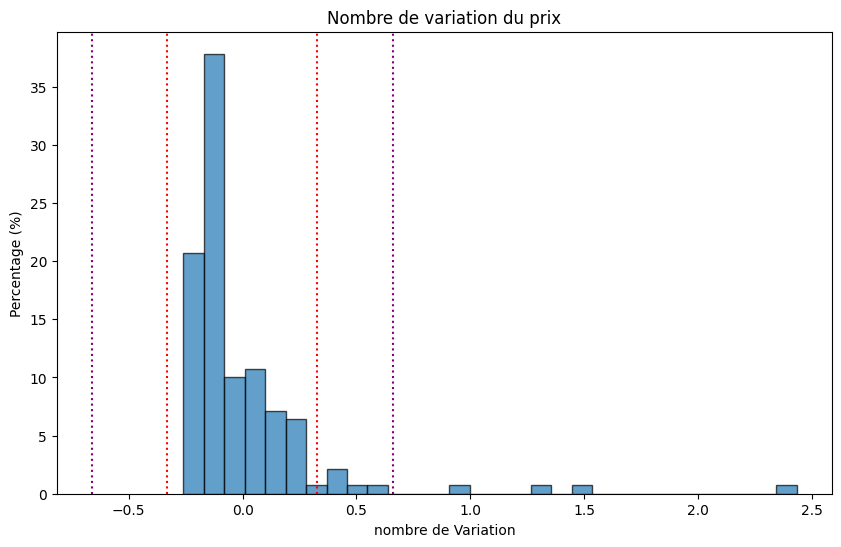

In [334]:
import matplotlib.pyplot as plt
import numpy as np

mean = stats_ID['normalized_variation'].mean()
std = stats_ID['normalized_variation'].std()

# Seuils à 2sd et 3sd
lower_1sd = mean - std
upper_1sd = mean + std
lower_2sd = mean - 2*std
upper_2sd = mean + 2*std


plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(stats_ID['normalized_variation'], bins=30, weights=(np.ones(len(stats_ID)) / len(stats_ID)) * 100, edgecolor='black', alpha=0.7)
plt.title('Nombre de variation du prix')
plt.axvline(lower_1sd, color='red', linestyle='dotted', label='2SD')
plt.axvline(upper_1sd, color='red', linestyle='dotted', label='2SD')
plt.axvline(lower_2sd, color='purple', linestyle='dotted', label='3SD')
plt.axvline(upper_2sd, color='purple', linestyle='dotted', label='3SD')
plt.xlabel("nombre de Variation")
plt.ylabel('Percentage (%)')
plt.show()

17% des paires sellers-products ne changent jamais leur prix et 43% d'entre eux le changent moins de 1% de fois sur toutes la longueur des observations.

In [335]:
counts = stats_ID.groupby(stats_ID['mean_ID'].round(2))['ID'].nunique().sort_index(ascending=True)

for change, count in counts.items():
    print(f"{round(change*100)}% de changement: {round((count/140)*100)}% des sellers-products")

0% de changement: 43% des sellers-products
1% de changement: 16% des sellers-products
2% de changement: 4% des sellers-products
3% de changement: 7% des sellers-products
4% de changement: 13% des sellers-products
5% de changement: 8% des sellers-products
7% de changement: 2% des sellers-products
9% de changement: 1% des sellers-products
10% de changement: 1% des sellers-products
11% de changement: 1% des sellers-products
13% de changement: 1% des sellers-products
24% de changement: 1% des sellers-products
25% de changement: 1% des sellers-products
37% de changement: 1% des sellers-products
65% de changement: 1% des sellers-products


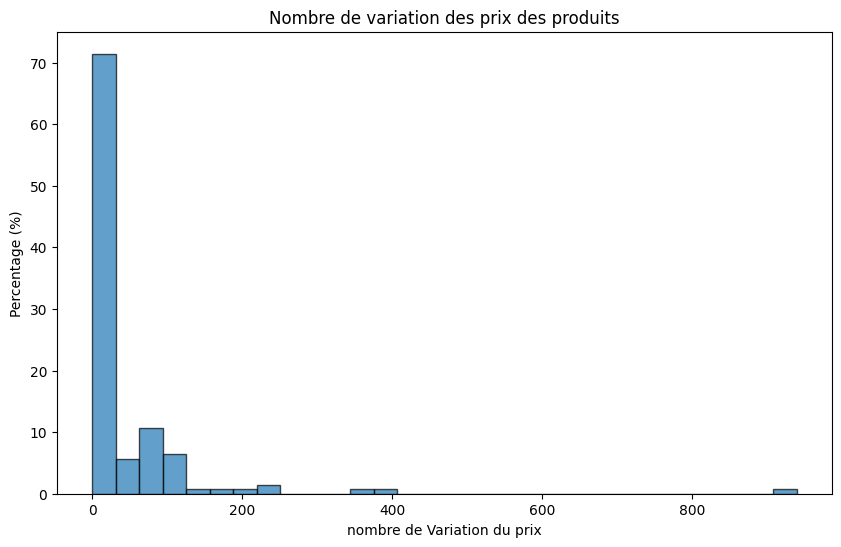

In [336]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(stats_ID['sum'], bins=30, weights=(np.ones(len(stats_ID)) / len(stats_ID)) * 100, edgecolor='black', alpha=0.7)
plt.title('Nombre de variation des prix des produits')
plt.xlabel("nombre de Variation du prix")
plt.ylabel('Percentage (%)')
plt.show()

In [337]:
algorithmic_pricing_1sd = stats_ID[stats_ID['is_algorithmic_pricing_1sd']]['ID'].unique()
algorithmic_pricing_2sd = stats_ID[stats_ID['is_algorithmic_pricing_2sd']]['ID'].unique()

In [338]:
print("Pourcentages des produits détectés comme algorithmiques avec 1SD:", (round(len(algorithmic_pricing_1sd)/len(df['ID'].unique())*100)),'%')
print("Pourcentages des produits détectés comme algorithmiques avec 2SD:", (round(len(algorithmic_pricing_2sd)/len(df['ID'].unique())*100)),'%')


Pourcentages des produits détectés comme algorithmiques avec 1SD: 7 %
Pourcentages des produits détectés comme algorithmiques avec 2SD: 3 %


Création de nouvelles colonnes dans le dataframe qui indique si le product-seller est algorithmique ou non pour chacun des critères

In [339]:
df['is_algorithmic_1sd'] = df['ID'].isin(algorithmic_pricing_1sd).astype(int)
df['is_algorithmic_2sd'] = df['ID'].isin(algorithmic_pricing_2sd).astype(int)


Création de la variable ``is_algorithmic_1sd_always`` et	``is_algorithmic_2sd_always`` qui classent un vendeur qui a au moins un produit algorithmique selon le critères 1SD ou 2SD comme algorithmique pour tous ses produits. 

In [340]:
sellers_algo_sd1 = df[df['is_algorithmic_1sd']==True]['Seller'].unique()
df['is_algorithmic_1sd_always']=  df['Seller'].isin(sellers_algo_sd1).astype(int)


sellers_algo_sd2 = df[df['is_algorithmic_2sd']==True]['Seller'].unique()
df['is_algorithmic_2sd_always']=  df['Seller'].isin(sellers_algo_sd2).astype(int)


In [341]:
df.drop(columns=['time_diff','price_previous','variation','variation_bool'],inplace=True)

Nous exportons ces données en csv pour pouvoir faire les utiliser pour la régression

In [342]:
df.to_csv('data_algo1.csv')

In [345]:
print('1SD              : Nombre de vendeurs algo',len(df[df['is_algorithmic_1sd']==1]['Seller'].unique()))
print('1SD              : Nombre de paires vendeur-produit algo',len(df[df['is_algorithmic_1sd']==1]['ID'].unique()))
print('1SD always       : Nombre de vendeurs algo',len(df[df['is_algorithmic_1sd_always']==1]['Seller'].unique()))
print('1SD always       : Nombre de paires vendeur-produit algo',len(df[df['is_algorithmic_1sd_always']==1]['ID'].unique()))
print('2SD              : Nombre de vendeurs algo',len(df[df['is_algorithmic_2sd']==1]['Seller'].unique()))
print('2SD              : Nombre de paires vendeur-produit algo',len(df[df['is_algorithmic_2sd']==1]['ID'].unique()))
print('2SD always       : Nombre de vendeurs algo',len(df[df['is_algorithmic_2sd_always']==1]['Seller'].unique()))
print('2SD always       : Nombre de paires vendeur-produit algo',len(df[df['is_algorithmic_2sd_always']==1]['ID'].unique()))

1SD              : Nombre de vendeurs algo 5
1SD              : Nombre de paires vendeur-produit algo 10
1SD always       : Nombre de vendeurs algo 5
1SD always       : Nombre de paires vendeur-produit algo 20
2SD              : Nombre de vendeurs algo 3
2SD              : Nombre de paires vendeur-produit algo 4
2SD always       : Nombre de vendeurs algo 3
2SD always       : Nombre de paires vendeur-produit algo 6


Nombre de paires **produits-vendeurs** considérées comme algorithmiques en fonction des méthodes :

| Méthode   | 1SD | 2SD |
|-----------|-----|-----|
| Sometimes | 10  | 4   |
| Always    | 20  | 6   |

Note: __sometimes__ signifie que ne sont classées comme algorithmiques que les paires vendeur-produit qui ont été détectées comme algorithmiques avec les critères 1SD et 2SD. 